In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Accuracy & Macro F1

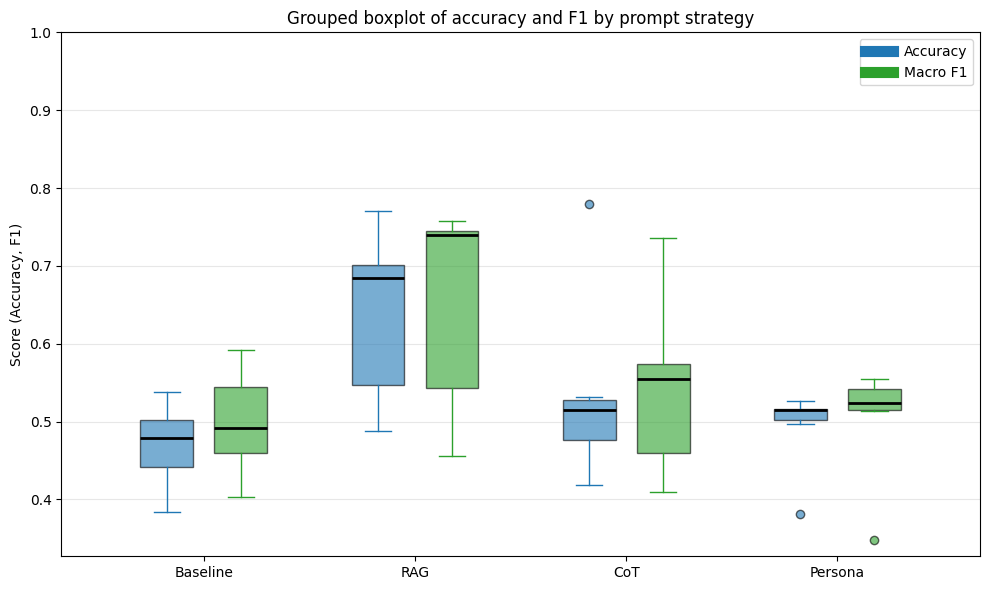

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------
# Data
# ----------------------
A = {
    "Baseline": [0.5134, 0.4122, 0.5383, 0.4717, 0.4792, 0.4911, 0.3841],
    "RAG":     [0.7710,  0.4879, 0.5951, 0.6843, 0.6983, 0.7027, 0.4986],
    "CoT":     [0.7792, 0.5240,  0.5149, 0.4559, 0.5313, 0.4973, 0.4183],
    "Persona": [0.5154, 0.4967, 0.5166, 0.5075, 0.5152, 0.5269, 0.3806]


}

B = {
    "Baseline": [0.5915,	0.4281,	0.5909,	0.4912,	0.4899,	0.4990,	0.4028],
    "RAG":     [0.7426,	0.4561,	0.5803,	0.7397,	0.7573,	0.7459,	0.5053],
    "CoT":     [0.7358,	0.5647,	0.5552,	0.4265,	0.5829,	0.4935,	0.4098],
    "Persona": [0.5545,	0.5241,	0.5355,	0.5473,	0.5154,	0.5134,	0.3484]

}

prompts = list(A.keys())
x = np.arange(len(prompts))
width = 0.35

plt.figure(figsize=(10, 6))

# ----------------------
# A (Blue)
# ----------------------
plt.boxplot(
    [A[p] for p in prompts],
    positions=x - width/2,
    widths=0.25,
    patch_artist=True,
    boxprops=dict(facecolor="tab:blue", alpha=0.6),
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(color="tab:blue"),
    capprops=dict(color="tab:blue"),
    flierprops=dict(markerfacecolor="tab:blue", alpha=0.6),
    showfliers=True
)

# ----------------------
# B (Green)
# ----------------------
plt.boxplot(
    [B[p] for p in prompts],
    positions=x + width/2,
    widths=0.25,
    patch_artist=True,
    boxprops=dict(facecolor="tab:green", alpha=0.6),
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(color="tab:green"),
    capprops=dict(color="tab:green"),
    flierprops=dict(markerfacecolor="tab:green", alpha=0.6),
    showfliers=True
)

# ----------------------
# Axis & legend
# ----------------------
plt.xticks(x, prompts)
plt.ylabel("Score (Accuracy, F1)")
plt.title("Grouped boxplot of accuracy and F1 by prompt strategy")

plt.ylim(top=1.0)


# Custom legend
blue_patch = plt.Line2D([0], [0], color="tab:blue", lw=8, label="Accuracy")
green_patch = plt.Line2D([0], [0], color="tab:green", lw=8, label="Macro F1")
plt.legend(handles=[blue_patch, green_patch])

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# McNemar Boxplot - Strategies

/tmp/ipykernel_1978/2721051315.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


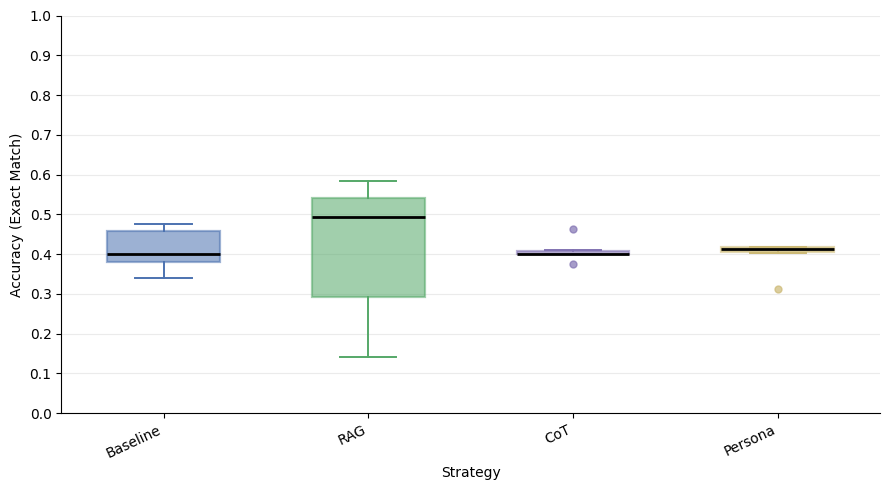

/tmp/ipykernel_1978/2721051315.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


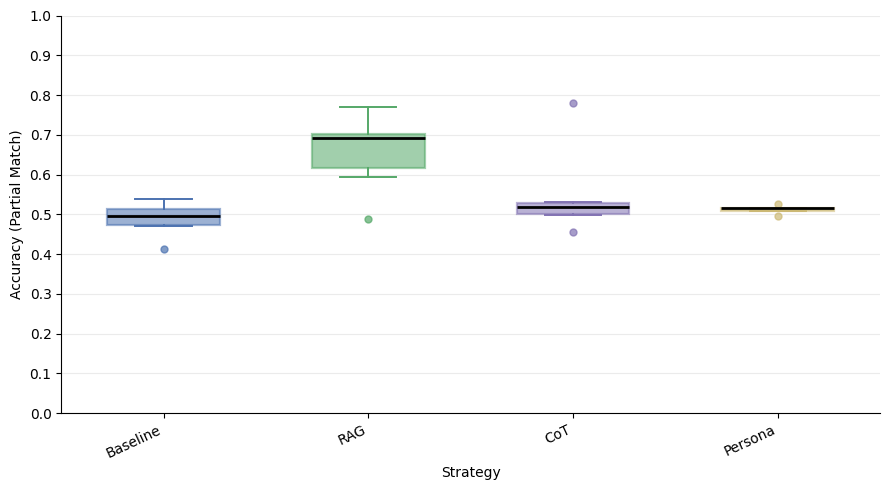

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

strategies = ["Baseline", "RAG", "CoT", "Persona"]

colors = {
    "Baseline": "#4C72B0",
    "RAG":      "#55A868",
    "CoT":      "#8172B2",
    "Persona":  "#CCB974",
}

exact_data = {
    "Baseline": [0.4751, 0.4751, 0.3396, 0.4099, 0.3772, 0.3892],
    "RAG":      [0.4929, 0.1408, 0.2240, 0.5843, 0.5559, 0.4959],
    "CoT":      [0.4630, 0.4100, 0.3997, 0.3747, 0.4004, 0.4017],
    "Persona":  [0.3122, 0.4040, 0.4186, 0.4185, 0.4117, 0.4160],
}

partial_data = {
    "Baseline": [0.5134, 0.5134, 0.4122, 0.5383, 0.4717, 0.4792],
    "RAG":      [0.7710, 0.4879, 0.5951, 0.6843, 0.6983, 0.7027],
    "CoT":      [0.7792, 0.5240, 0.5149, 0.4559, 0.5313, 0.4973],
    "Persona":  [0.5154, 0.4967, 0.5166, 0.5075, 0.5152, 0.5269],
}

def draw_boxplot_only(data_dict, ylabel, out_png=None):
    data = [data_dict[s] for s in strategies]

    fig, ax = plt.subplots(figsize=(9, 5))

    bp = ax.boxplot(
        data,
        labels=strategies,
        widths=0.55,
        patch_artist=True,
        showfliers=True,   # 이상치만 점으로 표시
        medianprops=dict(color="black", linewidth=2),
    )

    for i, s in enumerate(strategies):
        c = colors[s]

        bp["boxes"][i].set_facecolor(c)
        bp["boxes"][i].set_alpha(0.55)
        bp["boxes"][i].set_edgecolor(c)
        bp["boxes"][i].set_linewidth(1.6)

        bp["whiskers"][2*i].set_color(c)
        bp["whiskers"][2*i+1].set_color(c)
        bp["whiskers"][2*i].set_linewidth(1.4)
        bp["whiskers"][2*i+1].set_linewidth(1.4)

        bp["caps"][2*i].set_color(c)
        bp["caps"][2*i+1].set_color(c)
        bp["caps"][2*i].set_linewidth(1.4)
        bp["caps"][2*i+1].set_linewidth(1.4)

        if len(bp["fliers"]) > i:
            bp["fliers"][i].set_marker("o")
            bp["fliers"][i].set_markerfacecolor(c)
            bp["fliers"][i].set_markeredgecolor(c)
            bp["fliers"][i].set_alpha(0.7)
            bp["fliers"][i].set_markersize(5)

    ax.set_xlabel("Strategy")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0.0, 1.0)
    ax.set_yticks(np.arange(0.0, 1.01, 0.1))

    plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    if out_png:
        plt.savefig(out_png, dpi=300, bbox_inches="tight")

    plt.show()

draw_boxplot_only(exact_data, "Accuracy (Exact Match)", "boxplot_exact_only.png")
draw_boxplot_only(partial_data, "Accuracy (Partial Match)", "boxplot_partial_only.png")

# McNemar Boxplot - Models

/tmp/ipykernel_177/498238920.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


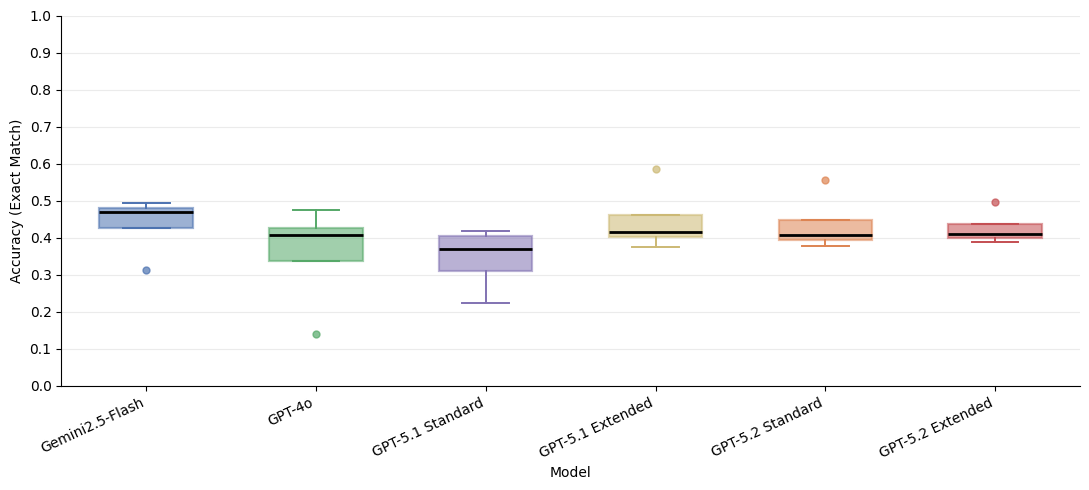

/tmp/ipykernel_177/498238920.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


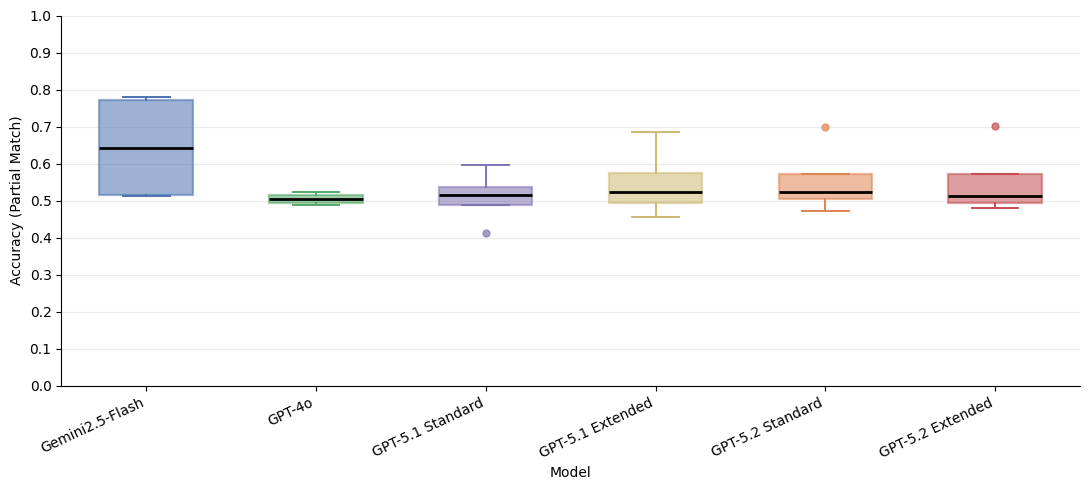

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------
# Settings
# ----------------------
models = ["gemini-2.5-flash", "gpt-4o", "gpt-5.1st", "gpt-5.1et", "gpt-5.2st", "gpt-5.2et"]

# x축에 표시할 이름만 따로 지정
display_labels = [
    "Gemini2.5-Flash",
    "GPT-4o",
    "GPT-5.1 Standard",
    "GPT-5.1 Extended",
    "GPT-5.2 Standard",
    "GPT-5.2 Extended",
]

# 각 박스 색상 (모델별)
colors = {
    "gemini-2.5-flash": "#4C72B0",  # muted blue
    "gpt-4o":           "#55A868",  # muted green
    "gpt-5.1st":        "#8172B2",  # muted purple
    "gpt-5.1et":        "#CCB974",  # muted yellow
    "gpt-5.2st":        "#DD8452",  # muted cyan
    "gpt-5.2et":        "#C44E52",  # muted red
}

# ----------------------
# Data
# 각 모델 박스 안에는 [Baseline, RAG, CoT, Persona] 순서의 값 4개가 들어감
# ----------------------

exact_data_by_model = {
    "gemini-2.5-flash": [0.4751, 0.4929, 0.4630, 0.3122],
    "gpt-4o":           [0.4751, 0.1408, 0.4100, 0.4040],
    "gpt-5.1st":        [0.3396, 0.2240, 0.3997, 0.4186],
    "gpt-5.1et":        [0.4099, 0.5843, 0.3747, 0.4185],
    "gpt-5.2st":        [0.3772, 0.5559, 0.4004, 0.4117],
    "gpt-5.2et":        [0.3892, 0.4959, 0.4017, 0.4160],
}

partial_data_by_model = {
    "gemini-2.5-flash": [0.5134, 0.7710, 0.7792, 0.5154],
    "gpt-4o":           [0.5134, 0.4879, 0.5240, 0.4967],
    "gpt-5.1st":        [0.4122, 0.5951, 0.5149, 0.5166],
    "gpt-5.1et":        [0.5383, 0.6843, 0.4559, 0.5075],
    "gpt-5.2st":        [0.4717, 0.6983, 0.5313, 0.5152],
    "gpt-5.2et":        [0.4792, 0.7027, 0.4973, 0.5269],
}

# ----------------------
# Boxplot function
# ----------------------
def draw_model_boxplot(data_dict, ylabel, out_png=None):
    data = [data_dict[m] for m in models]

    fig, ax = plt.subplots(figsize=(11, 5))

    bp = ax.boxplot(
        data,
        labels=display_labels,   # 여기만 변경
        widths=0.55,
        patch_artist=True,
        showfliers=True,   # 점은 이상치만 표시
        medianprops=dict(color="black", linewidth=2),
    )

    for i, m in enumerate(models):
        c = colors[m]

        # box
        bp["boxes"][i].set_facecolor(c)
        bp["boxes"][i].set_alpha(0.55)
        bp["boxes"][i].set_edgecolor(c)
        bp["boxes"][i].set_linewidth(1.6)

        # whiskers
        bp["whiskers"][2*i].set_color(c)
        bp["whiskers"][2*i+1].set_color(c)
        bp["whiskers"][2*i].set_linewidth(1.4)
        bp["whiskers"][2*i+1].set_linewidth(1.4)

        # caps
        bp["caps"][2*i].set_color(c)
        bp["caps"][2*i+1].set_color(c)
        bp["caps"][2*i].set_linewidth(1.4)
        bp["caps"][2*i+1].set_linewidth(1.4)

        # outliers
        if len(bp["fliers"]) > i:
            bp["fliers"][i].set_marker("o")
            bp["fliers"][i].set_markerfacecolor(c)
            bp["fliers"][i].set_markeredgecolor(c)
            bp["fliers"][i].set_alpha(0.7)
            bp["fliers"][i].set_markersize(5)

    ax.set_title("")
    ax.set_xlabel("Model")
    ax.set_ylabel(ylabel)

    # y축 0.0 ~ 1.0, 0.1 간격
    ax.set_ylim(0.0, 1.0)
    ax.set_yticks(np.arange(0.0, 1.01, 0.1))

    plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    if out_png:
        plt.savefig(out_png, dpi=300, bbox_inches="tight")

    plt.show()

# ----------------------
# Draw 2 separate graphs
# ----------------------
draw_model_boxplot(
    exact_data_by_model,
    "Accuracy (Exact Match)",
    out_png="boxplot_model_x_exact_match.png"
)

draw_model_boxplot(
    partial_data_by_model,
    "Accuracy (Partial Match)",
    out_png="boxplot_model_x_partial_match.png"
)